In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from data.instructions import instructions_v819

## Look at the instruction token count

In [2]:
# Estimate the token count for system prompt, conservatively using 2 tokens per char
len(instructions_v819) / 2

4961.0

## Look at input & output token counts from past runs

In [3]:
past_df = pd.read_csv("data/claude_raw_results.csv")
past_df.head()

,citing_cluster_id,model,input_tokens,output_tokens,raw_results
0,2620779,us.anthropic.claude-3-7-sonnet-20250219-v1:0,3486.0,172.0,"[{'uniqueID': '1447641', 'targetName': 'Hodges..."
1,105846,us.anthropic.claude-3-7-sonnet-20250219-v1:0,3526.0,376.0,"[{'uniqueID': '105837', 'targetName': 'Kermare..."
2,100915,us.anthropic.claude-3-7-sonnet-20250219-v1:0,5586.0,367.0,"[{'uniqueID': '96357', 'targetName': 'South Ca..."
3,105845,us.anthropic.claude-3-7-sonnet-20250219-v1:0,3587.0,471.0,"[{'uniqueID': '105825', 'targetName': 'Romero ..."
4,2147,us.anthropic.claude-3-7-sonnet-20250219-v1:0,5715.0,1182.0,"[{'uniqueID': '2556', 'targetName': 'Bonime v...."


In [4]:
past_df["input_tokens"].describe()

count       307.000000
mean      22839.843648
std       17770.607420
min        3486.000000
25%       11946.000000
50%       17526.000000
75%       30233.500000
max      133112.000000
Name: input_tokens, dtype: float64

In [5]:
past_df["input_tokens"].sum()

np.float64(7011832.0)

In [6]:
past_df["output_tokens"].describe()

count     307.000000
mean     3419.843648
std      1970.754012
min       159.000000
25%      2008.500000
50%      3014.000000
75%      4814.000000
max      8023.000000
Name: output_tokens, dtype: float64

## Look at data from CLReplica

In [7]:
df = pd.read_csv("data/cluster_data.csv")
len(df)

6647123

In [8]:
## Calculate the correlation between opinion text length and num_authorities
correlation = df["opinion_text_length"].corr(df["num_authorities"])
print(f"Correlation between opinion text length and num_authorities: {correlation:.4f}")

Correlation between opinion text length and num_authorities: 0.7776


## Remove records with 0 authorities

In [9]:
df = df[df["num_authorities"] > 0]
len(df)

4856202

## Get records from appeals court

In [10]:
fed_appeals_courts = ["scotus", "cafc", "ca1", "ca2", "ca3", "ca4", "ca5", "ca6", "ca7", "ca8", "ca9", "ca10", "ca11", "cadc"]
state_supreme_courts = ["ala", "alaska", "ariz", "ark", "cal", "colo", "conn", "del", "dc", "fla",
                        "ga", "haw", "idaho", "ill", "ind", "iowa", "kan", "ky", "la", "me",
                        "md", "mass", "mich", "minn", "miss", "mo", "mont", "neb", "nev", "nh",
                        "nj", "nm", "ny", "nc", "nd", "ohio", "okla", "or", "pa", "ri",
                        "sc", "sd", "tenn", "tex", "texcrimapp", "utah", "vt", "va", "wash", "wva",
                        "wis", "wyo", "guam", "nmariana", "prsupreme", "virginislands", "amsamoa"]
state_appeals_courts = ["alacrimapp", "alacivapp", "alaskactapp", "arizctapp", "arkctapp",
                        "calctapp", "calappdeptsuper", "coloctapp", "connappct", "connsuperct",
                        "delch", "delsuperct", "fladistctapp", "gactapp", "hawapp",
                        "idahoctapp", "illappct", "indctapp", "iowactapp", "kanctapp",
                        "kyctapp", "lactapp", "mdctspecapp", "massappct", "masssuperct",
                        "massdistct", "michctapp", "minnctapp", "missctapp", "moctapp",
                        "nebctapp", "nevapp", "njsuperctappdiv", "nmctapp", "nyappdiv",
                        "nyappterm", "ncctapp", "ncsuperct", "ndctapp", "ohioctapp",
                        "oklacivapp", "oklacrimapp", "orctapp", "pasuperct", "pacommwct",
                        "risuperct", "scctapp", "tennctapp", "tenncrimapp", "texapp",
                        "texjpml", "utahctapp", "vtsuperct", "vactapp", "washctapp",
                        "wvactapp", "wisctapp", "superctguam", "prapp"]

appeals_courts = fed_appeals_courts + state_supreme_courts + state_appeals_courts

In [11]:
appeals_courts_df = df[df["court"].isin(appeals_courts)]
len(appeals_courts_df)

3555355

## IQR method to identify records that have been "heavily cited"

Q1: 0.0, Q3: 6.0, IQR: 6.0
Upper bound (Q3 + 1.5*IQR): 15.0

Records above upper bound: 614,486 (12.7%)
Records at or below:       4,241,716


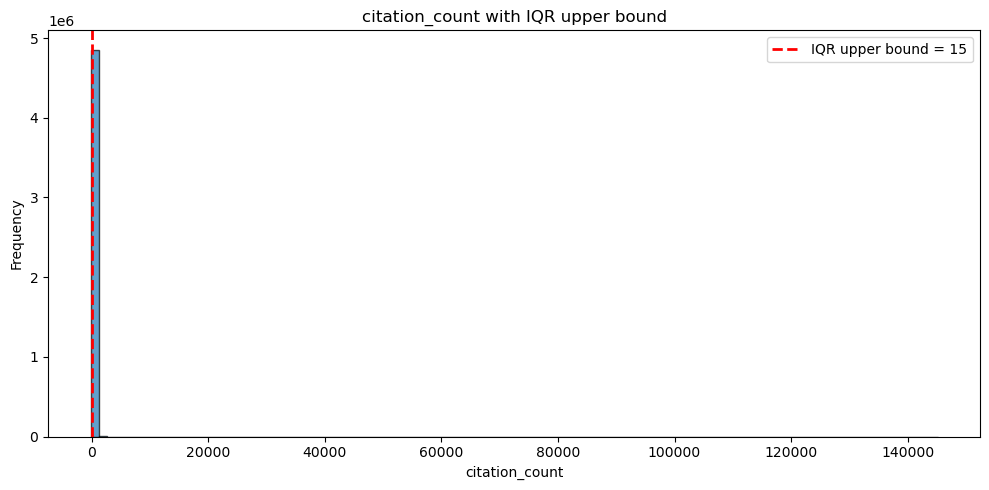

count    614486.000000
mean         69.022780
std         474.267203
min          16.000000
25%          21.000000
50%          31.000000
75%          57.000000
max      145148.000000
Name: citation_count, dtype: float64

In [12]:
Q1 = df["citation_count"].quantile(0.25)
Q3 = df["citation_count"].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Upper bound (Q3 + 1.5*IQR): {upper_bound}")

heavily_cited = df[df["citation_count"] > upper_bound]
print(f"\nRecords above upper bound: {len(heavily_cited):,} ({len(heavily_cited)/len(df)*100:.1f}%)")
print(f"Records at or below:       {len(df) - len(heavily_cited):,}")


fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df["citation_count"], bins=100, edgecolor="black", alpha=0.7)
ax.axvline(upper_bound, color="red", linestyle="--", linewidth=2, label=f"IQR upper bound = {upper_bound:.0f}")
ax.set_title("citation_count with IQR upper bound")
ax.set_xlabel("citation_count")
ax.set_ylabel("Frequency")
ax.legend()
plt.tight_layout()
plt.show()

heavily_cited["citation_count"].describe()

## IQR method to identify records that have abnormally large number of "authorities" or abnormally long opinion text

Q1: 3.0, Q3: 15.0, IQR: 12.0
Outliers (Q3 + 1.5*IQR): 33.0

Records above outliers: 278,998 (5.7%)
Records at or below:       4,577,204


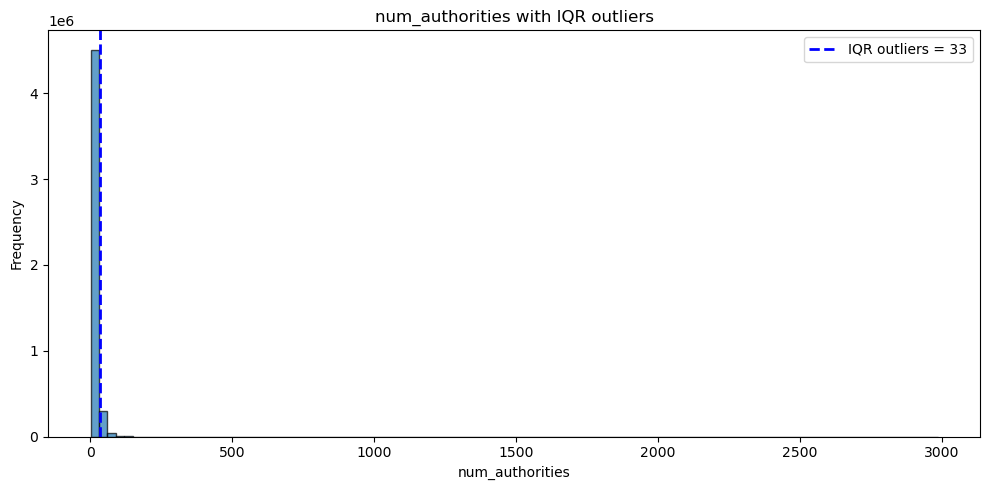

count    278998.000000
mean         50.159370
std          23.449156
min          34.000000
25%          37.000000
50%          43.000000
75%          55.000000
max        2985.000000
Name: num_authorities, dtype: float64

In [13]:
Q1 = df["num_authorities"].quantile(0.25)
Q3 = df["num_authorities"].quantile(0.75)
IQR = Q3 - Q1
auth_outliers_bound = Q3 + 1.5 * IQR

print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Outliers (Q3 + 1.5*IQR): {auth_outliers_bound}")

auth_outliers = df[df["num_authorities"] > auth_outliers_bound]
print(f"\nRecords above outliers: {len(auth_outliers):,} ({len(auth_outliers)/len(df)*100:.1f}%)")
print(f"Records at or below:       {len(df) - len(auth_outliers):,}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df["num_authorities"], bins=100, edgecolor="black", alpha=0.7)
ax.axvline(auth_outliers_bound, color="blue", linestyle="--", linewidth=2, label=f"IQR outliers = {auth_outliers_bound:.0f}")
ax.set_title("num_authorities with IQR outliers")
ax.set_xlabel("num_authorities")
ax.set_ylabel("Frequency")
ax.legend()
plt.tight_layout()
plt.show()

auth_outliers["num_authorities"].describe()

Q1: 6468.0, Q3: 32431.0, IQR: 25963.0
Outliers (Q3 + 1.5*IQR): 71375.5

Records above outliers: 319,594 (6.6%)
Records at or below:       4,536,608


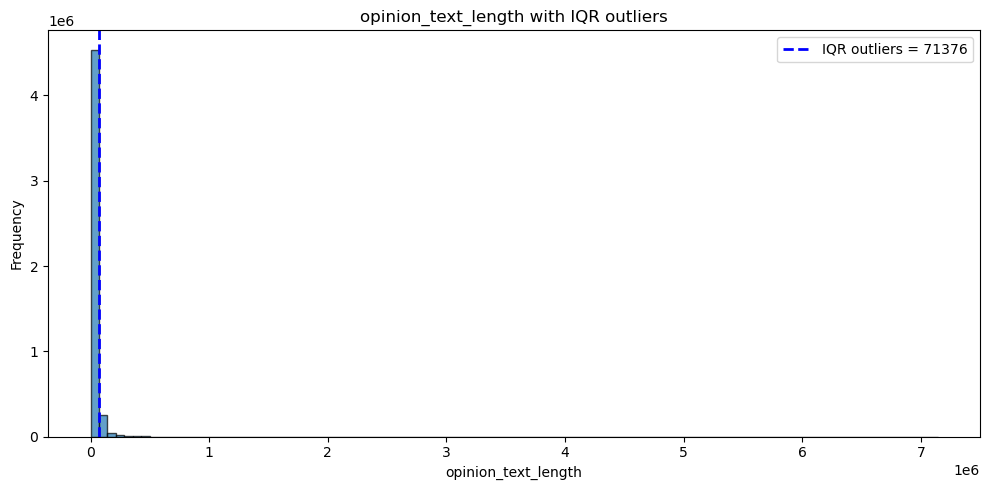

count    3.195940e+05
mean     1.223122e+05
std      8.655359e+04
min      7.137600e+04
25%      8.177000e+04
50%      9.787750e+04
75%      1.309710e+05
max      7.141315e+06
Name: opinion_text_length, dtype: float64

In [14]:
Q1 = df["opinion_text_length"].quantile(0.25)
Q3 = df["opinion_text_length"].quantile(0.75)
IQR = Q3 - Q1
text_outliers_bound = Q3 + 1.5 * IQR

print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Outliers (Q3 + 1.5*IQR): {text_outliers_bound}")

## Visualize the outliers cutoff
length_outliers = df[df["opinion_text_length"] > text_outliers_bound]
print(f"\nRecords above outliers: {len(length_outliers):,} ({len(length_outliers)/len(df)*100:.1f}%)")
print(f"Records at or below:       {len(df) - len(length_outliers):,}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df["opinion_text_length"], bins=100, edgecolor="black", alpha=0.7)
ax.axvline(text_outliers_bound, color="blue", linestyle="--", linewidth=2, label=f"IQR outliers = {text_outliers_bound:.0f}")
ax.set_title("opinion_text_length with IQR outliers")
ax.set_xlabel("opinion_text_length")
ax.set_ylabel("Frequency")
ax.legend()
plt.tight_layout()
plt.show()

length_outliers["opinion_text_length"].describe()

## Get records that have been heavily cited

In [15]:
heavily_cited_df = df[df["citation_count"] >= upper_bound]
len(heavily_cited_df)

651199

## Find any records that have been heavily cited but not within the appeals courts

In [16]:
heavily_cited_df[~heavily_cited_df["cluster_id"].isin(appeals_courts_df["cluster_id"].unique())]

,cluster_id,court,num_authorities,opinion_text_length,citation_count
601700,779850,fiscr,29,151728,79
619183,797333,uscfc,17,73679,20
622051,800201,armfor,27,114216,39
622053,800203,armfor,17,82789,26
622055,800205,armfor,12,30999,49
...,...,...,...,...,...
6472886,10620209,nysupctnewyork,33,193878,95
6513903,10661996,texbizct,63,98060,22
6521301,10669471,bia,25,55230,445
6544716,10693535,nhd,23,41439,24


## Find any records that have been heavily cited but also part of the extreme outliers for "number of authorities" and "text length"

In [17]:
special_df = heavily_cited_df[(heavily_cited_df["cluster_id"].isin(auth_outliers["cluster_id"].unique())) | (heavily_cited_df["cluster_id"].isin(length_outliers["cluster_id"].unique()))]
special_df

,cluster_id,court,num_authorities,opinion_text_length,citation_count
1,2,ca1,114,143960,92
12,13,ca1,34,53100,124
17,18,ca1,35,52258,64
23,24,ca1,35,45821,31
26,27,ca1,38,53852,79
...,...,...,...,...,...
6645651,10797901,wash,50,238197,24
6645653,10797903,wash,26,124143,21
6645655,10797905,wash,125,313857,107
6645725,10797975,wash,66,203635,19


In [18]:
print("SPECIAL RECORDS - Num Requests:", len(special_df))
print("SPECIAL RECORDS - Input Length:", special_df["opinion_text_length"].sum())

SPECIAL RECORDS - Num Requests: 161298
SPECIAL RECORDS - Input Length: 19603673201


## Remove records with authorities or text length outliers

In [19]:
len(df)

4856202

In [20]:
df = df[(~df["cluster_id"].isin(auth_outliers["cluster_id"].unique())) & (~df["cluster_id"].isin(length_outliers["cluster_id"].unique()))]
print("ALL COURTS - Num Requests:", len(df))
print("ALL COURTS - Input Length:", df["opinion_text_length"].sum())

ALL COURTS - Num Requests: 4433180
ALL COURTS - Input Length: 81376006348


## Get records from either appeals court or have been heavily cited

In [21]:
appeals_df = df[(df["citation_count"] >= upper_bound) | (df["court"].isin(appeals_courts))]
print("APPEALS COURTS - Num Requests:", len(appeals_df))
print("APPEALS COURTS - Input Length:", appeals_df["opinion_text_length"].sum())

APPEALS COURTS - Num Requests: 3328698
APPEALS COURTS - Input Length: 57206856818


## Get records from either federal appeals courts or state courts of last resort or have been heavily cited

In [22]:
fed_state_df = df[(df["citation_count"] >= upper_bound) | (df["court"].isin(fed_appeals_courts + state_supreme_courts))]
print("FEDERAL APPEALS & STATE COLR - Num Requests:", len(fed_state_df))
print("FEDERAL APPEALS & STATE COLR - Input Length:", fed_state_df["opinion_text_length"].sum())

FEDERAL APPEALS & STATE COLR - Num Requests: 1556278
FEDERAL APPEALS & STATE COLR - Input Length: 28991045407


## Get records from either federal appeals courts or have been heavily cited

In [23]:
fed_df = df[(df["citation_count"] >= upper_bound) | (df["court"].isin(fed_appeals_courts))]
print("FEDERAL APPEALS COURTS - Num Requests:", len(fed_df))
print("FEDERAL APPEALS COURTS - Input Length:", fed_df["opinion_text_length"].sum())

FEDERAL APPEALS COURTS - Num Requests: 1202298
FEDERAL APPEALS COURTS - Input Length: 23410588909
